In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import seaborn as sns
import math

from sklearn.base import BaseEstimator, TransformerMixin



In [14]:
# 1. Load the data from the CSV file into a pandas DataFrame
# https://www.kaggle.com/c/titanic/data
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
# Check for Missing Data
missing_cols = df.isna().any()
if missing_cols.any():
    cols_with_missing = missing_cols[missing_cols].index
    for col in cols_with_missing:
        print(f"Data Missing in {col}")
else:
    print("No Missing Data in Any Column")

Data Missing in Age
Data Missing in Cabin
Data Missing in Embarked


In [16]:
target = 'Survived'
features = [col for col in df.columns if col != target and col]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Exploratory Categorical
survival_rate_proportion_sex = df.groupby('Sex')['Survived'].mean()
survival_rate_proportion_pclass = df.groupby('Pclass')['Survived'].mean()
survival_rate_proportion_embarked = df.groupby('Embarked')['Survived'].mean()
missing_age_proportion = df["Age"].isnull().mean()
missing_cabin_proportion = df["Cabin"].isnull().mean()
missing_embarked_proportion = df["Embarked"].isnull().mean()

print(f'Missing Cabin {missing_cabin_proportion:,.4f}')
print(f'Missing Age {missing_age_proportion:,.4f}')
print(f'Missing Embarked {missing_embarked_proportion:,.4f}')

print(survival_rate_proportion_sex)
print(survival_rate_proportion_pclass)
print(survival_rate_proportion_embarked)

# Variablity - Not interpretable - Simple stats is interpratable such as simple linear regression - Want to know why people survive - 
# Correlation between survival and cabin - interaction affects and spurrous relationship affects - Ice cream greater chance of drowning
# Bootstrap - take sample and resample for estimate varaiacne in dataset 

# logistical variables looks at categorial variables
# multivariable lr models - adds up to a probaility
# Multicollinearity - multiibple variables say the same thing. Regression model - highly correlated with each other. Identy these before training
# Correlation matrix - between multipile variable at a time.

Missing Cabin 0.7710
Missing Age 0.1987
Missing Embarked 0.0022
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


AgeGroup
Child      0.579710
Adult      0.387597
Unknown    0.293785
Name: Survived, dtype: float64
FamilyGroup
Alone    0.303538
Small    0.578767
Large    0.161290
Name: Survived, dtype: float64


/var/folders/x0/dd1k8z7n1vv3hz8l45gqyk9w0000gn/T/ipykernel_91994/2081662599.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_by_age = df.groupby('AgeGroup')['Survived'].mean()
/var/folders/x0/dd1k8z7n1vv3hz8l45gqyk9w0000gn/T/ipykernel_91994/2081662599.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_by_family = df.groupby('FamilyGroup')['Survived'].mean()


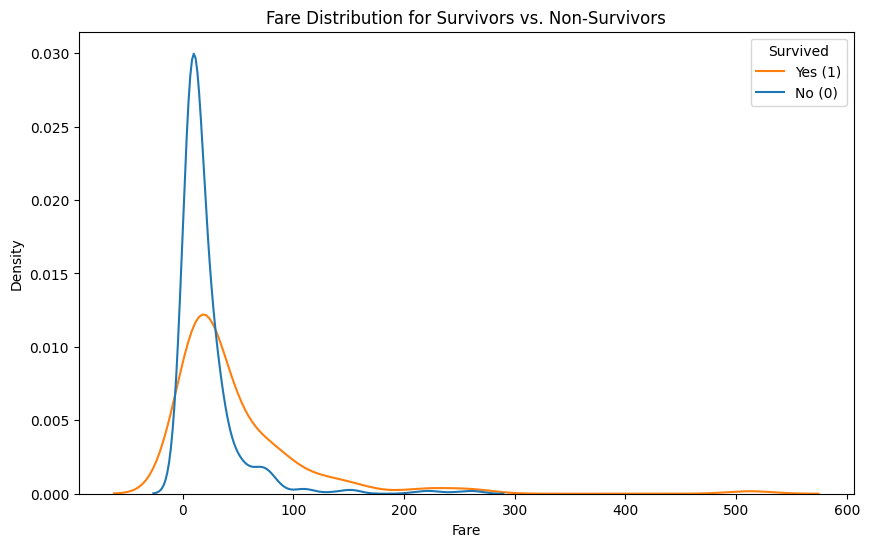

In [18]:
# Exploratory Numerical
bins = [0, 12, 100]
labels = ['Child', 'Adult']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
df['AgeGroup'] = df['AgeGroup'].cat.add_categories('Unknown')
df['AgeGroup'] = df['AgeGroup'].fillna('Unknown')

survival_rate_by_age = df.groupby('AgeGroup')['Survived'].mean()
print(survival_rate_by_age)

labels = ['Alone', 'Small', 'Large']
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
bins = [0, 1, 4, df['FamilySize'].max()]
df['FamilyGroup'] = pd.cut(df['FamilySize'], bins=bins, labels=labels, right=True)

survival_rate_by_family = df.groupby('FamilyGroup')['Survived'].mean() 
print(survival_rate_by_family)


plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Fare', hue='Survived', common_norm=False)
plt.title('Fare Distribution for Survivors vs. Non-Survivors')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.legend(title='Survived', labels=['Yes (1)', 'No (0)'])
plt.show()

In [19]:
def extract_cabin_letter(X):
    """
    Extracts the first letter from the 'Cabin' column (first column of X),
    fills missing values with 'U', and reshapes for the pipeline.
    """
    cabin_series = X.iloc[:, 0]
    letters = cabin_series.str[0]
    return letters.values.reshape(-1, 1)

def create_family_groups(X):
    """
    Takes a DataFrame/array with 'SibSp' and 'Parch' (in that order),
    calculates FamilySize, and bins it.
    """
    family_size = X.sum(axis=1) + 1
    bins = [0, 1, 4, np.inf]
    labels = ['Alone', 'Small', 'Large']
    groups = pd.cut(family_size, bins=bins, labels=labels, right=True)
    
    return groups.astype(str).values.reshape(-1, 1)

def check_has_cabin(X):
    """
    Takes the 'Cabin' column, checks for nulls,
    and returns 1 (HasCabin) or 0 (NoCabin).
    """
    cabin_series = pd.Series(X.iloc[:, 0]) 
    has_cabin = cabin_series.notnull().astype(int)
    return has_cabin.values.reshape(-1, 1)

def check_is_alone(X):
    """
    Takes a DataFrame/array with 'SibSp' and 'Parch' (in that order),
    calculates FamilySize, and returns 1 if FamilySize==1, else 0.
    """
    family_size = X.sum(axis=1) + 1
    is_alone = (family_size == 1).astype(int)
    
    return is_alone.values.reshape(-1, 1)


class FareTicketTransformer(BaseEstimator, TransformerMixin):
    """
    Custom transformer that takes 'Ticket' and 'Fare' columns.
    
    It learns the frequency of each ticket from the training data.
    
    It outputs two new features:
    1. TicketFrequency: The count of that ticket in the training set.
    2. FarePerPerson: The 'Fare' divided by the 'TicketFrequency'.
    """
    def __init__(self):
        pass

    def fit(self, X, y=None):
        ticket_series = pd.Series(X.iloc[:, 0]) 
        self.ticket_counts_ = ticket_series.value_counts().to_dict()
        return self

    def transform(self, X, y=None):
        tickets = pd.Series(X.iloc[:, 0])
        fares = pd.Series(X.iloc[:, 1])
        
        ticket_freq = tickets.map(self.ticket_counts_).fillna(1)
        fare_per_person = fares / ticket_freq
        
        return np.stack([ticket_freq, fare_per_person], axis=1)

In [ ]:
numeric_features = ['Age'] 
categorical_features = ['Sex', 'Embarked']
ordinal_features = ['Pclass']
cabin_features = ['Cabin']
family_features = ['SibSp', 'Parch']
fare_ticket_features = ['Ticket', 'Fare']

fare_ticket_transformer = Pipeline(steps=[
    ('fare_ticket', FareTicketTransformer()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

family_transformer = Pipeline(steps=[
    ('create_groups', FunctionTransformer(create_family_groups)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

is_alone_transformer = Pipeline(steps=[
    ('check_alone', FunctionTransformer(check_is_alone))
])

has_cabin_transformer = Pipeline(steps=[
    ('check_cabin', FunctionTransformer(check_has_cabin))
]) 

cabin_transformer = Pipeline(steps=[
    ('get_letter', FunctionTransformer(extract_cabin_letter)),
    ('imputer', SimpleImputer(strategy='most_frequent')), # 'U' is most frequent
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OrdinalEncoder(categories=[[1, 2, 3]])) 
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('ord', ordinal_transformer, ordinal_features), 
        ('family_group', family_transformer, family_features),
        ('is_alone', is_alone_transformer, family_features),
        ('has_cabin', has_cabin_transformer, cabin_features),
        ('fare_and_ticket', fare_ticket_transformer, fare_ticket_features)
    ],
    remainder='drop' # Drops columns not specified (like 'Name', 'PassengerId')
)


pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


param_grid = {
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [3, 5, 7, 10]
}
grid_search = GridSearchCV(estimator=pipe_rf, param_grid=param_grid, cv=5)

models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "Random Forest - Grid": grid_search
}

cv_results = []
scoring_metrics = ['accuracy']

for name, model in models.items():
    print(f"Running Cross-Validation for: {name}...")
    # Use cross_validate to get multiple scores at once
    scores = cross_validate(model, X_train, y_train, cv=5, scoring=scoring_metrics)
    
    cv_results.append({
        "Model": name,
        "Avg. Accuracy": f"{scores['test_accuracy'].mean():.4f}",
    })

# Print the results in a table format
print("\nTable 3: Cross-Validated Model Performance Comparison")
results_df = pd.DataFrame(cv_results).set_index('Model')
print(results_df)

Running Cross-Validation for: Logistic Regression...


Running Cross-Validation for: Random Forest...
Running Cross-Validation for: Random Forest - Grid...

Table 3: Cross-Validated Model Performance Comparison
                     Avg. Accuracy
Model                             
Logistic Regression         0.8089
Random Forest               0.7992
Random Forest - Grid        0.8188


Logistic Regression...
Model Accuracy on Test Set: 0.8101
Random Forest...
Model Accuracy on Test Set: 0.8156
Random Forest - Grid...
Model Accuracy on Test Set: 0.8101


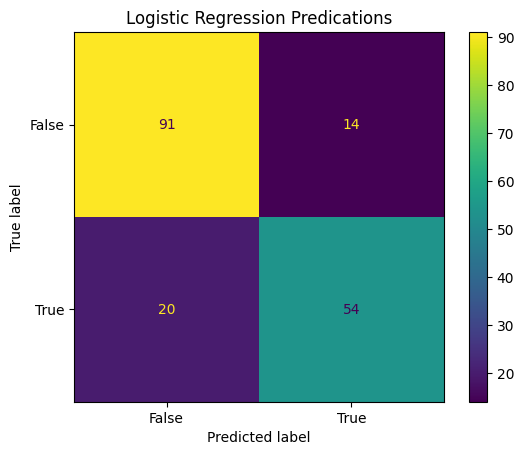

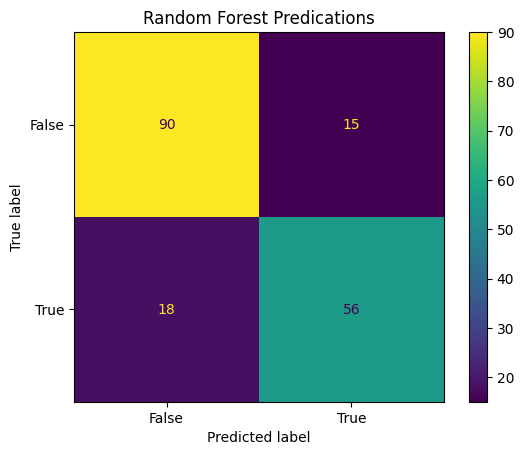

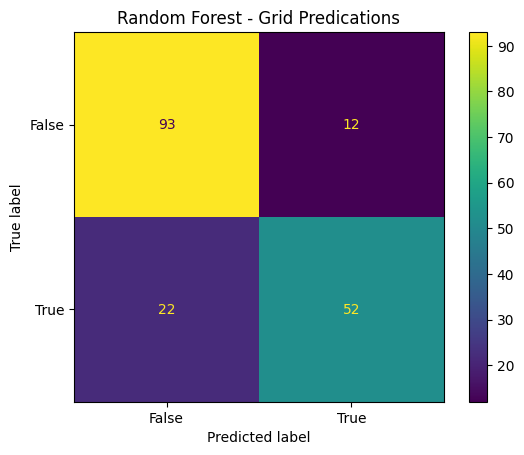

In [21]:
for name, model in models.items():
    print(f"{name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy on Test Set: {accuracy:.4f}")
    class_names = y.astype(bool).unique().tolist()
    cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names) 
    cm.ax_.set_title(f"{name} Predications")
    cm


In [22]:
grid_search = models['Random Forest - Grid']
print(f"\nBest parameters found by GridSearchCV: {grid_search.best_params_}")
best_model = grid_search.best_estimator_
tuned_accuracy = best_model.score(X_test, y_test)
print(f"Tuned Model Accuracy: {tuned_accuracy:.4f}")



Best parameters found by GridSearchCV: {'classifier__criterion': 'gini', 'classifier__max_depth': 5}
Tuned Model Accuracy: 0.8101


In [23]:
new_passengers = pd.DataFrame({
    'Pclass': [1, 3, 2],
    'Sex': ['female', 'male', 'female'],
    'Age': [35, 22, 5],
    'Fare': [80.0, 7.25, 26.0],
    'Embarked': ['S', 'S', 'C'],
    'SibSp': [1, 0, 1],
    'Parch': [0, 0, 2],
    'Ticket': ['PC 17595', 'A/5 21171', '230136'],
    'Cabin': ['E34', np.nan, np.nan]
})

predictions = best_model.predict(new_passengers)
prediction_text = ['Survived' if p == 1 else 'Did not Survive' for p in predictions]

print("\n--- Example Predictions ---")
for i, (index, passenger) in enumerate(new_passengers.iterrows()):
    print(f"Prediction for passenger {i+1} ({passenger['Sex']}, age {passenger['Age']}, class {passenger['Pclass']}): {prediction_text[i]}")
print("-" * 30)



--- Example Predictions ---
Prediction for passenger 1 (female, age 35, class 1): Survived
Prediction for passenger 2 (male, age 22, class 3): Did not Survive
Prediction for passenger 3 (female, age 5, class 2): Survived
------------------------------


In [24]:
import pickle

with open('best_model - titanic.pkl', 'wb') as f:
    pickle.dump(pipe_rf, f)